# routines

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from fooof import FOOOF
from scipy.signal import welch
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import mne
import ast
import json
import ast
import pickle
from matplotlib.patches import ConnectionPatch

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


C:\Users\verga\AppData\Local\Temp\ipykernel_25812\2742484954.py:5: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:
plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 14,
    "font.weight": "bold",              # <--- AGGIUNTO
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False



# fig X

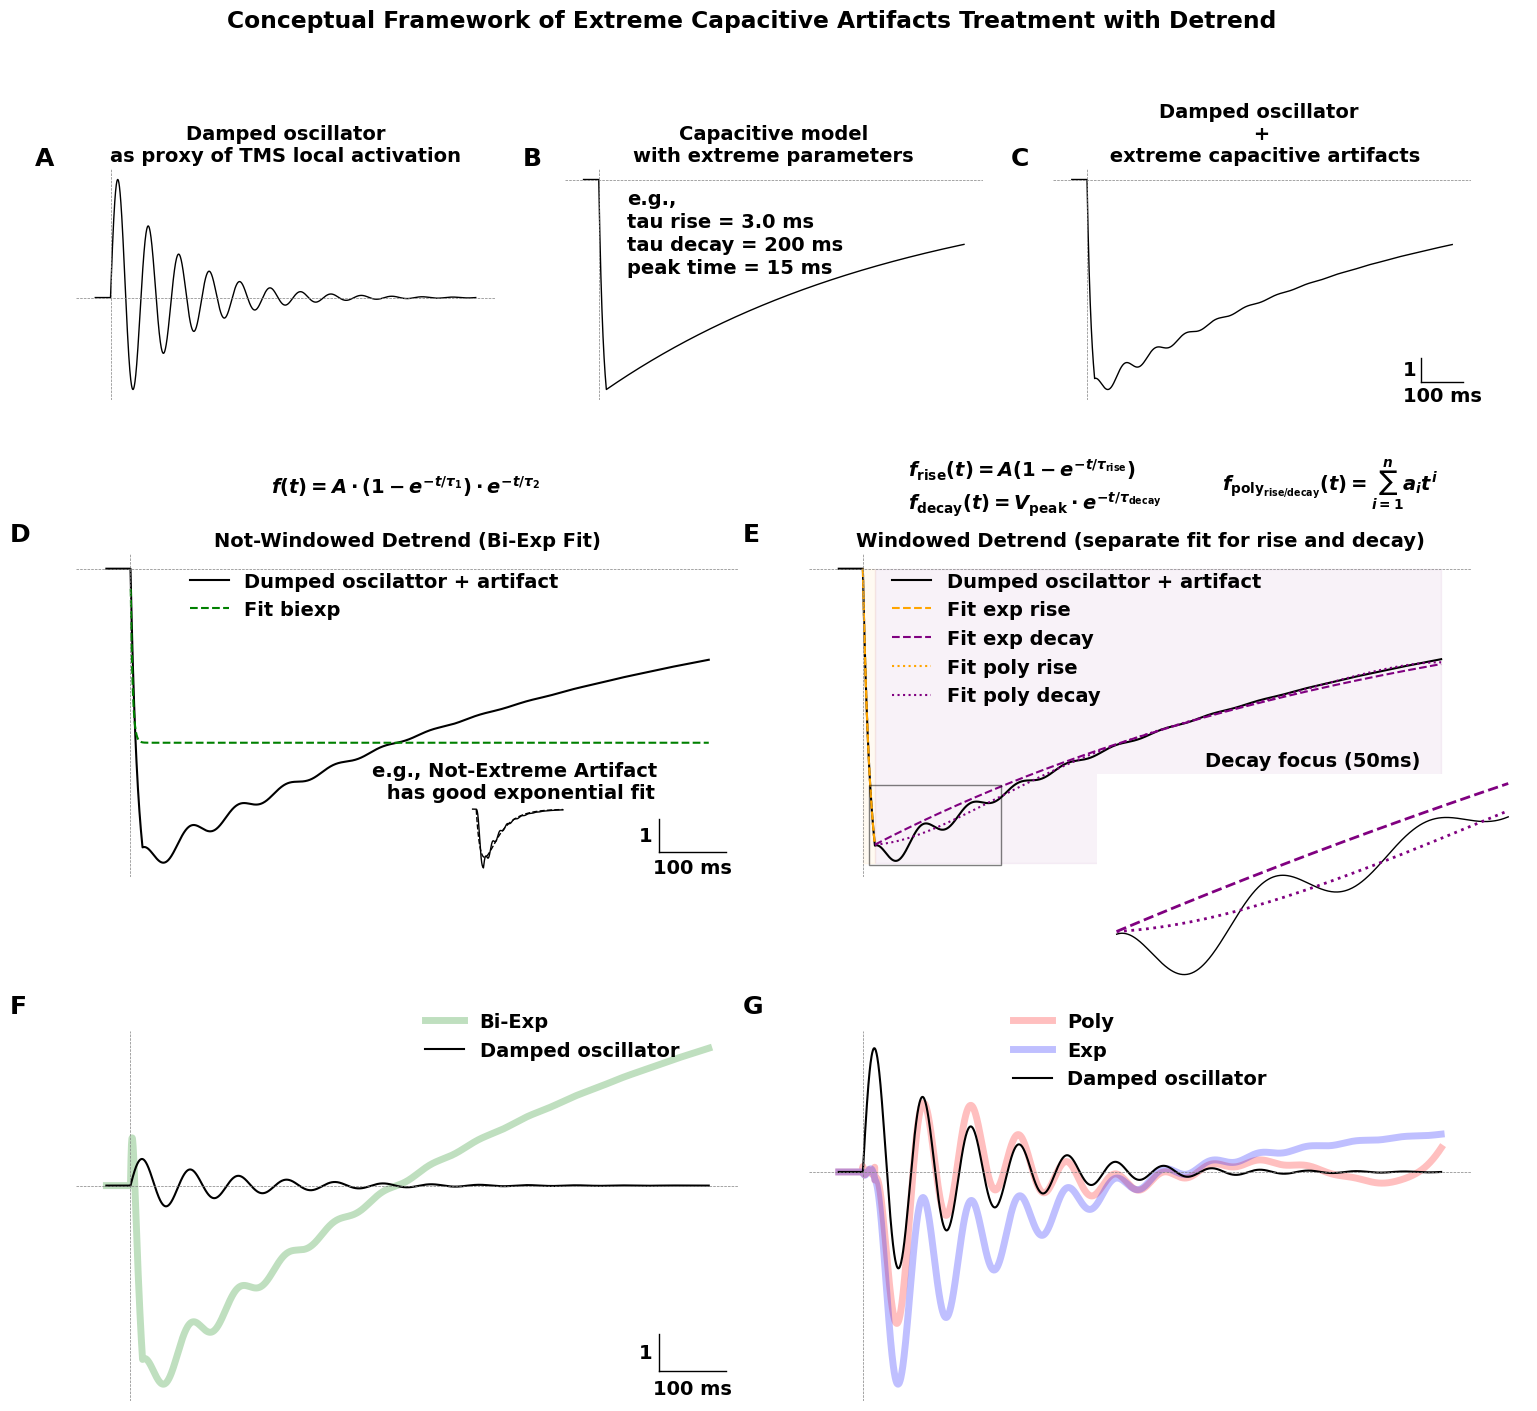

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Parametri temporali
t_start = 0
t_end = 250
dt = 0.1
t = np.arange(t_start, t_end, dt)

# Parametri oscillatore smorzato
A = 5.0
f = 50.0
lambda_ = 25
t0 = 10

# Oscillatore smorzato
y = np.zeros_like(t)
mask = t >= t0 
t_shifted = t[mask] - t0 
y[mask] = A * np.exp(-lambda_ * t_shifted / 1000) * np.sin(2 * np.pi * f * t_shifted / 1000)

# Funzione carica-scarica
def carica_scarica(t, t0, t_peak, tauRise, tauDecay):
    V0 = 1.0
    signal = np.zeros_like(t)
    for i, ti in enumerate(t):
        if ti < t0:
            signal[i] = 0
        elif ti < t_peak:
            signal[i] = V0 * (1 - np.exp(-(ti - t0) / tauRise))
        else:
            V_peak = V0 * (1 - np.exp(-(t_peak - t0) / tauRise))
            signal[i] = V_peak * np.exp(-(ti - t_peak) / tauDecay)
    return signal

# Parametri carica-scarica
t_peak = 15
tauRise = t_peak/5
tauDecay = 200
k = 100
charge = -carica_scarica(t, t0, t_peak, tauRise, tauDecay) * k
sum_signal = y + charge

def biexp(t, A, tau1, tau2):
    t_adj = np.clip(np.asarray(t) - t0, 0, None)
    return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)

mask_fit = t > t0
t_fit = t[mask_fit]
popt, _ = curve_fit(biexp, t_fit, sum_signal[mask_fit], p0=[tauRise, 50, 100])
fit_curve = biexp(t_fit, *popt)  # <-- questa è la riga corretta

# Fit rise/decay
mask_rise = (t >= t0) & (t < t_peak)
t_rise = t[mask_rise]
y_rise = sum_signal[mask_rise]

def exp_rise(t, A, tau):
    t_adj = np.clip(np.asarray(t) - t0, 0, None)
    return A * (1 - np.exp(-t_adj / tau))

popt_rise, _ = curve_fit(exp_rise, t_rise, y_rise, p0=[5, 10])
fit_rise = exp_rise(t_rise, *popt_rise)

# Aggiorna V_peak
V_peak = exp_rise(t_peak, *popt_rise)

mask_decay = t >= t_peak
t_decay = t[mask_decay]
y_decay = sum_signal[mask_decay]
V_peak = exp_rise(t_peak, *popt_rise)

def exp_decay_constrained(t, tau):
    return V_peak * np.exp(-(t - t_peak) / tau)

popt_decay, _ = curve_fit(exp_decay_constrained, t_decay, y_decay, p0=[100])
fit_decay = exp_decay_constrained(t_decay, *popt_decay)

# Fit polinomiale vincolato
degree = 5
t_decay_shifted = t_decay - t_peak
y_decay_shifted = y_decay - V_peak
X = np.vstack([t_decay_shifted**i for i in range(1, degree + 1)]).T
coeffs_constrained = np.linalg.lstsq(X, y_decay_shifted, rcond=None)[0]
fit_poly_decay = V_peak + X @ coeffs_constrained
fit_poly_rise = np.polyval(np.polyfit(t_rise, y_rise, 3), t_rise)

# Residui
resid_biexp = np.zeros_like(t)
resid_biexp[mask_fit] = sum_signal[mask_fit] - fit_curve
resid_exp = np.zeros_like(t)
resid_exp[mask_rise] = sum_signal[mask_rise] - fit_rise
resid_exp[mask_decay] = sum_signal[mask_decay] - fit_decay
resid_poly = np.zeros_like(t)
resid_poly[mask_rise] = sum_signal[mask_rise] - fit_poly_rise
resid_poly[mask_decay] = sum_signal[mask_decay] - fit_poly_decay

# Errori
mse_biexp = mean_squared_error(sum_signal[mask_fit], fit_curve)
mae_biexp = mean_absolute_error(sum_signal[mask_fit], fit_curve)
mse_exp = mean_squared_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_rise, fit_decay]))
mae_exp = mean_absolute_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_rise, fit_decay]))
mse_poly = mean_squared_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_poly_rise, fit_poly_decay]))
mae_poly = mean_absolute_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_poly_rise, fit_poly_decay]))

# ─── Nuovo segnale con tauRise più lento (100 ms), decay invariato ───────
tauRise_inset = tauRise*20
tauDecay_inset = tauDecay*0.25
charge_inset = -carica_scarica(t, t0, t_peak*2, tauRise_inset, tauDecay_inset) * k
sum_signal_inset = y + charge_inset
mask_fit = t > t0
t_fit = t[mask_fit]
popt_inset, _ = curve_fit(biexp, t_fit, sum_signal_inset[mask_fit], p0=[tauRise, 50, 100])
fit_curve_inset = biexp(t_fit, *popt_inset)

def add_scale_symbol(ax, dx=0.1, dy=0.1):
    # Coordinate in assi (0–1)
    x0, y0 = 0.88, 0.08  # in basso a destra
    ax.plot([x0, x0 + dx], [y0, y0], color='black', lw=1, transform=ax.transAxes, clip_on=False)
    ax.plot([x0, x0], [y0, y0 + dy], color='black', lw=1, transform=ax.transAxes, clip_on=False)
    ax.text(x0 + dx/2, y0 - 0.02, '100 ms', ha='center', va='top', transform=ax.transAxes)
    ax.text(x0 - 0.01, y0 + dy/2, '1', ha='right', va='center', transform=ax.transAxes)

def base_axis(ax):
    ax.spines[:].set_visible(False)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(t0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_xlabel('')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 16))
fig.suptitle('Conceptual Framework of Extreme Capacitive Artifacts Treatment with Detrend', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(
    3, 6,                # 3 righe, 6 colonne
    height_ratios=[1, 1.4, 1.6],
    width_ratios=[1]*6,  # 6 colonne tutte uguali
    hspace=0.5,
    wspace=0.4
)

# ─── Prima riga: 3 pannelli ciascuno largo 2 colonne ───────────
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])
ax2 = fig.add_subplot(gs[0, 4:6])

# ─── Terza riga: due pannelli ciascuno largo 3 colonne ────────────
ax_left  = fig.add_subplot(gs[2, 0:3])
ax_right = fig.add_subplot(gs[2, 3:6])

ax0.plot(t, y, color='black', lw=1)
ax1.plot(t, charge, color='black', lw=1)
ax2.plot(t, sum_signal, color='black', lw=1)
base_axis(ax0)
base_axis(ax1)
base_axis(ax2)
add_scale_symbol(ax2)
ax0.set_title('Damped oscillator\nas proxy of TMS local activation')
ax1.set_title('Capacitive model\nwith extreme parameters')
ax2.set_title('Damped oscillator \n + \n extreme capacitive artifacts')
ax1.text(0.05*3, 1-0.15, f'e.g.,', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.9-0.15, f'tau rise = {tauRise} ms', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.8-0.15, f'tau decay = {tauDecay} ms', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.7-0.15, f'peak time = {t_peak} ms', transform=ax1.transAxes, ha='left')

# ─── Seconda riga: due pannelli ciascuno largo 3 colonne ────────────
ax3_left  = fig.add_subplot(gs[1, 0:3])
ax3_right = fig.add_subplot(gs[1, 3:6])
ax3_left.plot(t, sum_signal, color='k', label='Dumped oscilattor + artifact')
ax3_left.plot(t_fit, fit_curve, '--', color='green', label='Fit biexp')
ax3_left.set_title(
    r'Not-Windowed Detrend (Bi-Exp Fit)')
ax3_left.text(0.7, 1.25,
    r'$f(t) = A \cdot \left(1 - e^{-t/\tau_1} \right) \cdot e^{-t/\tau_2}$',
    transform=ax3_left.transAxes, va='top', ha='right'
)
ax3_left.legend(
    loc='upper center',
    bbox_to_anchor=(0.45, 1),
    ncol=1,
    frameon=False
)


ax3_right.set_title('Windowed Detrend (Rise and Decay fits)', y=1)
base_axis(ax3_left)
add_scale_symbol(ax3_left)
ax3_right.plot(t, sum_signal, color='k', label='Dumped oscilattor + artifact')
ax3_right.plot(t_rise, fit_rise, '--', color='orange', label='Fit exp rise')
ax3_right.plot(t_decay, fit_decay, '--', color='purple', label='Fit exp decay')
ax3_right.plot(t_rise, fit_poly_rise, ':', color='orange', label='Fit poly rise')
ax3_right.plot(t_decay, fit_poly_decay, ':', color='purple', label='Fit poly decay')
ax3_right.set_title('Windowed Detrend (separate fit for rise and decay)', y=1)
ax3_right.text(
    0.15, 1.3,
    r'$f_{\mathrm{rise}}(t) = A(1 - e^{-t/\tau_{\mathrm{rise}}})$',
    transform=ax3_right.transAxes,
    va='top', ha='left',
    color='k'
)
ax3_right.text(
    0.15, 1.2,
    r'$f_{\mathrm{decay}}(t) = V_{\mathrm{peak}} \cdot e^{-t/\tau_{\mathrm{decay}}}$',
    transform=ax3_right.transAxes,
    va='top', ha='left',
    color='k'
)
ax3_right.text(
    0.95, 1.3,
    r'$f_{\mathrm{poly}_\mathrm{rise/decay}}(t) = \sum_{i=1}^{n} a_i t^i$',
    transform=ax3_right.transAxes,
    va='top', ha='right'
)

y_min = np.min(sum_signal) - 0.5  # margine extra
ax3_right.fill(
    [t0, t_peak, t_peak, t0],
    [y_min, y_min, 0, 0],
    color='orange', alpha=0.05
)
ax3_right.fill(
    [t_peak, t[-1], t[-1], t_peak],
    [y_min, y_min, 0, 0],
    color='purple', alpha=0.05
)

base_axis(ax3_right)
ax3_right.legend(
    loc='upper left',
    bbox_to_anchor=(0.1, 1),
    ncol=1,
    frameon=False
)


from mpl_toolkits.axes_grid1.inset_locator import inset_axes
inset_decay = inset_axes(
    ax3_right,
    width="65%", height="65%",
    loc='upper right',
    bbox_to_anchor=(0.1, -0.65, 1, 1),
    bbox_transform=ax3_right.transAxes
)

# Finestra dei primi 50 ms del decay
start_focus = t_peak
end_focus = t_peak + 50
mask_focus = (t_decay >= start_focus) & (t_decay <= end_focus)
t_focus = t_decay[mask_focus]
signal_decay_focus = y_decay[mask_focus]
fit_decay_focus = fit_decay[mask_focus]
fit_poly_decay_focus = fit_poly_decay[mask_focus]  # aggiunto

# Tracce
inset_decay.plot(t_focus, signal_decay_focus, color='k', lw=1, label='Artifacted Damped Oscillator')
inset_decay.plot(t_focus, fit_decay_focus, '--', color='purple', lw=2)
inset_decay.plot(t_focus, fit_poly_decay_focus, ':', color='purple', lw=2)  # polinomiale
inset_decay.set_title('Decay focus (50ms)')
# Pulizia grafica
inset_decay.set_xticks([])
inset_decay.set_yticks([])
for spine in inset_decay.spines.values():
    spine.set_visible(False)
# Evidenzia zona dell'inset nel grafico principale
ax3_right.indicate_inset_zoom(inset_decay, edgecolor='k', linewidth=1, alpha=0.5)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Crea inset in basso a destra di ax3
inset_ax = inset_axes(ax3_left, width="15%", height="20%", loc='lower right', borderpad=2, bbox_to_anchor=(-0.05*4, -0.1, 1, 1), bbox_transform=ax3_left.transAxes)
inset_ax.plot(t_fit, fit_curve_inset, '--', color='black', lw=1)
inset_ax.plot(t, sum_signal_inset, color='k', lw=1, label='Artifacted Damped Oscillator')
inset_ax.set_title('e.g., Not-Extreme Artifact \n has good exponential fit')
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xticklabels([])
inset_ax.set_yticklabels([])
for spine in inset_ax.spines.values():
    spine.set_visible(False)

# PLOT RESIDUI
ax_left.plot(t, resid_biexp, '-', label=f'Bi-Exp', color='green', linewidth=5, alpha=.25)
ax_left.plot(t, y, '-', c='k', alpha=1, label='Damped oscillator')
ax_left.set_title(' ')
ax_left.set_xlabel(' ')
base_axis(ax_left)
add_scale_symbol(ax_left)
ax_left.legend(
    loc='upper left',
    bbox_to_anchor=(0.5, 1.1),
    ncol=1,
    frameon=False
)

#ax_right.plot(t, resid_exp, '-', label=f'exp\nMSE={mse_exp:.2f}, MAE={mae_exp:.2f}', color='b')
#ax_right.plot(t, resid_poly, '-', label=f'poly\nMSE={mse_poly:.2f}, MAE={mae_poly:.2f}', color='r')
ax_right.plot(t, resid_poly, '-', label='Poly',  color='r', linewidth=5, alpha=.25)
ax_right.plot(t, resid_exp, '-', label='Exp', color='b', linewidth=5, alpha=.25)
ax_right.plot(t, y, '-', c='k', alpha=1, label='Damped oscillator')
ax_right.set_title(' ')
ax_right.set_xlabel(' ')
base_axis(ax_right)
ax_right.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=1,
    frameon=False
)

# Lettere nei pannelli principali (in alto a sinistra)
for i, ax in enumerate([ax0, ax1, ax2, ax3_left, ax3_right, ax_left, ax_right]):
    ax.text(-0.1, 1.1, chr(65 + i), transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left')

plt.tight_layout()
# Salvataggio
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/FigureA.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./paperFigures/FigureA.png", format="png", bbox_inches="tight")
fig.savefig("./paperFigures/FigureA.svg", format="svg", bbox_inches="tight")

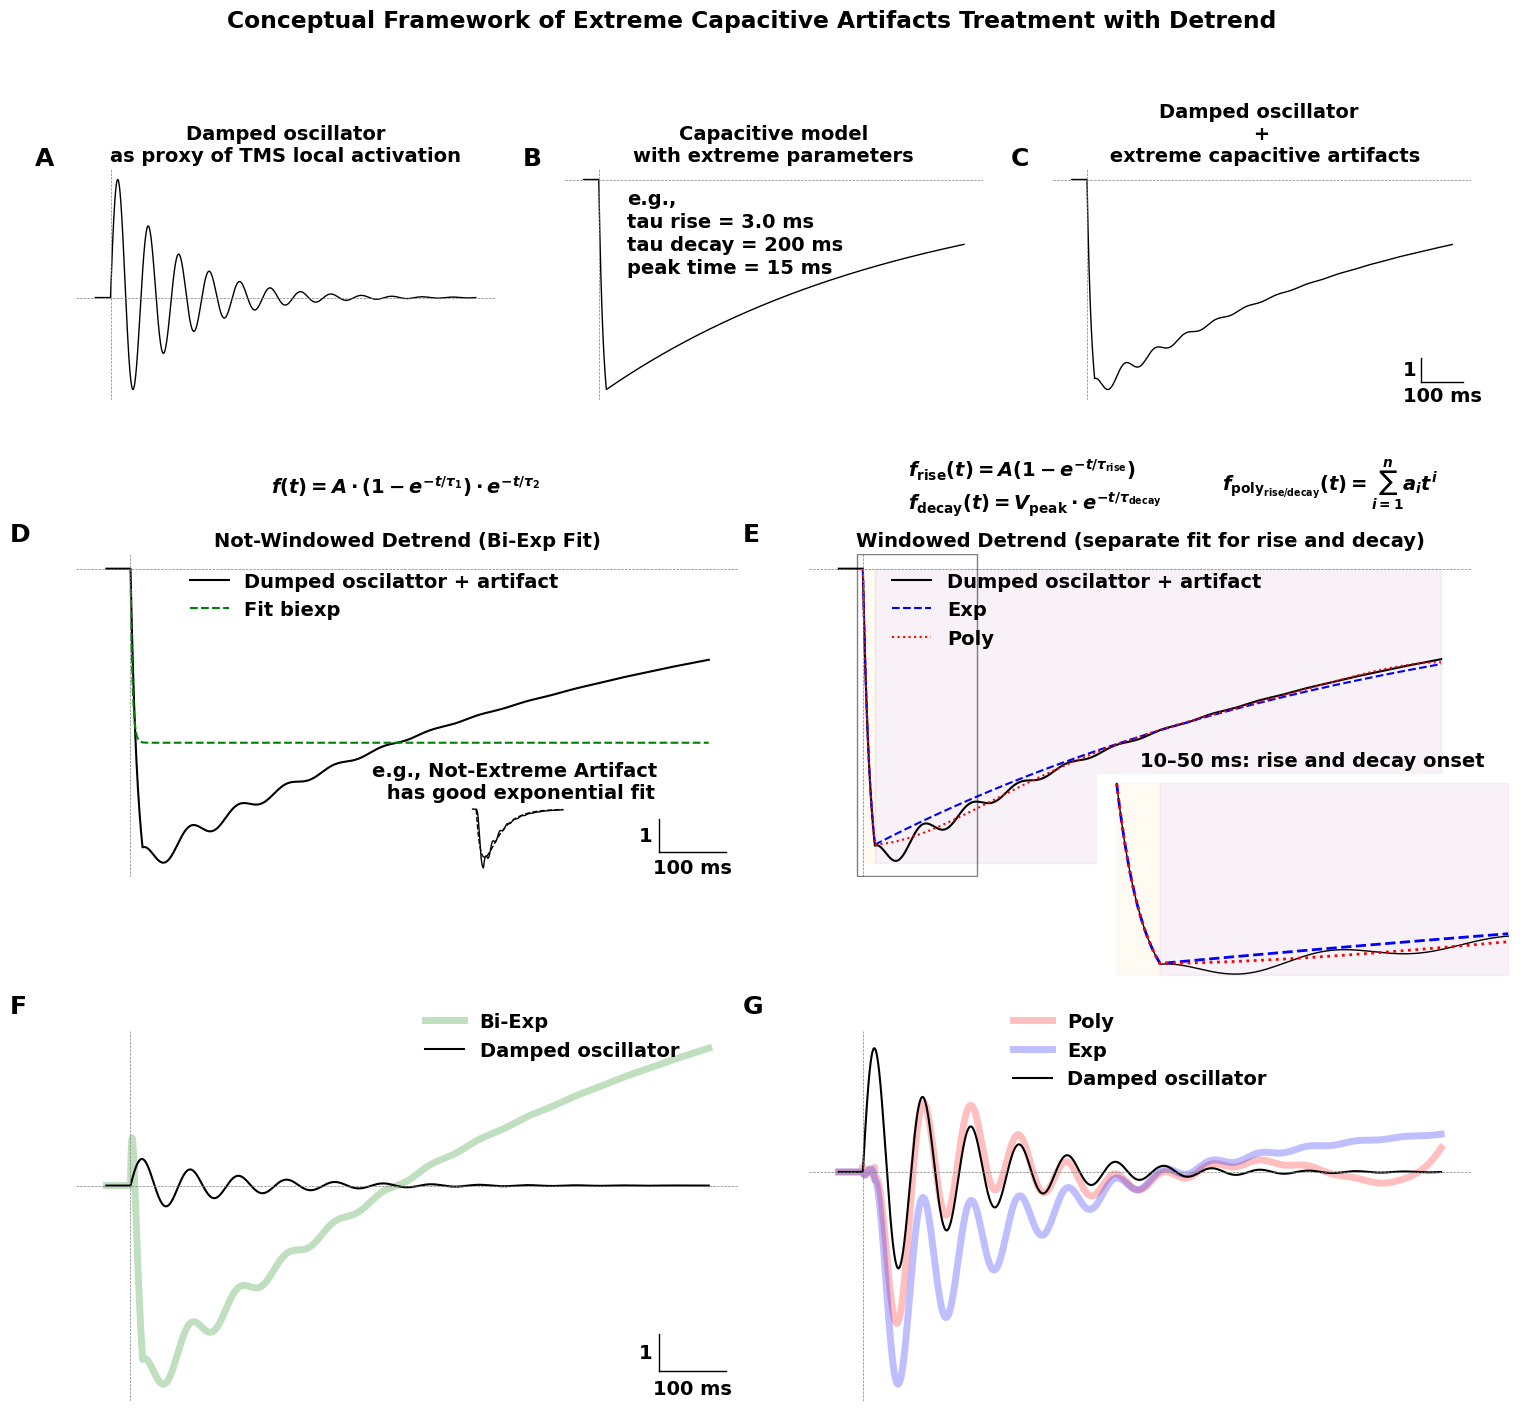

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Parametri temporali
t_start = 0
t_end = 250
dt = 0.1
t = np.arange(t_start, t_end, dt)

# Parametri oscillatore smorzato
A = 5.0
f = 50.0
lambda_ = 25
t0 = 10

# Oscillatore smorzato
y = np.zeros_like(t)
mask = t >= t0 
t_shifted = t[mask] - t0 
y[mask] = A * np.exp(-lambda_ * t_shifted / 1000) * np.sin(2 * np.pi * f * t_shifted / 1000)

# Funzione carica-scarica
def carica_scarica(t, t0, t_peak, tauRise, tauDecay):
    V0 = 1.0
    signal = np.zeros_like(t)
    for i, ti in enumerate(t):
        if ti < t0:
            signal[i] = 0
        elif ti < t_peak:
            signal[i] = V0 * (1 - np.exp(-(ti - t0) / tauRise))
        else:
            V_peak = V0 * (1 - np.exp(-(t_peak - t0) / tauRise))
            signal[i] = V_peak * np.exp(-(ti - t_peak) / tauDecay)
    return signal

# Parametri carica-scarica
t_peak = 15
tauRise = t_peak/5
tauDecay = 200
k = 100
charge = -carica_scarica(t, t0, t_peak, tauRise, tauDecay) * k
sum_signal = y + charge

def biexp(t, A, tau1, tau2):
    t_adj = np.clip(np.asarray(t) - t0, 0, None)
    return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)

mask_fit = t > t0
t_fit = t[mask_fit]
popt, _ = curve_fit(biexp, t_fit, sum_signal[mask_fit], p0=[tauRise, 50, 100])
fit_curve = biexp(t_fit, *popt)  # <-- questa è la riga corretta

# Fit rise/decay
mask_rise = (t >= t0) & (t < t_peak)
t_rise = t[mask_rise]
y_rise = sum_signal[mask_rise]

def exp_rise(t, A, tau):
    t_adj = np.clip(np.asarray(t) - t0, 0, None)
    return A * (1 - np.exp(-t_adj / tau))

popt_rise, _ = curve_fit(exp_rise, t_rise, y_rise, p0=[5, 10])
fit_rise = exp_rise(t_rise, *popt_rise)

# Aggiorna V_peak
V_peak = exp_rise(t_peak, *popt_rise)

mask_decay = t >= t_peak
t_decay = t[mask_decay]
y_decay = sum_signal[mask_decay]
V_peak = exp_rise(t_peak, *popt_rise)

def exp_decay_constrained(t, tau):
    return V_peak * np.exp(-(t - t_peak) / tau)

popt_decay, _ = curve_fit(exp_decay_constrained, t_decay, y_decay, p0=[100])
fit_decay = exp_decay_constrained(t_decay, *popt_decay)

# Fit polinomiale vincolato
degree = 5
t_decay_shifted = t_decay - t_peak
y_decay_shifted = y_decay - V_peak
X = np.vstack([t_decay_shifted**i for i in range(1, degree + 1)]).T
coeffs_constrained = np.linalg.lstsq(X, y_decay_shifted, rcond=None)[0]
fit_poly_decay = V_peak + X @ coeffs_constrained
fit_poly_rise = np.polyval(np.polyfit(t_rise, y_rise, 3), t_rise)

# Residui
resid_biexp = np.zeros_like(t)
resid_biexp[mask_fit] = sum_signal[mask_fit] - fit_curve
resid_exp = np.zeros_like(t)
resid_exp[mask_rise] = sum_signal[mask_rise] - fit_rise
resid_exp[mask_decay] = sum_signal[mask_decay] - fit_decay
resid_poly = np.zeros_like(t)
resid_poly[mask_rise] = sum_signal[mask_rise] - fit_poly_rise
resid_poly[mask_decay] = sum_signal[mask_decay] - fit_poly_decay

# Errori
mse_biexp = mean_squared_error(sum_signal[mask_fit], fit_curve)
mae_biexp = mean_absolute_error(sum_signal[mask_fit], fit_curve)
mse_exp = mean_squared_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_rise, fit_decay]))
mae_exp = mean_absolute_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_rise, fit_decay]))
mse_poly = mean_squared_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_poly_rise, fit_poly_decay]))
mae_poly = mean_absolute_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_poly_rise, fit_poly_decay]))

# ─── Nuovo segnale con tauRise più lento (100 ms), decay invariato ───────
tauRise_inset = tauRise*20
tauDecay_inset = tauDecay*0.25
charge_inset = -carica_scarica(t, t0, t_peak*2, tauRise_inset, tauDecay_inset) * k
sum_signal_inset = y + charge_inset
mask_fit = t > t0
t_fit = t[mask_fit]
popt_inset, _ = curve_fit(biexp, t_fit, sum_signal_inset[mask_fit], p0=[tauRise, 50, 100])
fit_curve_inset = biexp(t_fit, *popt_inset)

def add_scale_symbol(ax, dx=0.1, dy=0.1):
    # Coordinate in assi (0–1)
    x0, y0 = 0.88, 0.08  # in basso a destra
    ax.plot([x0, x0 + dx], [y0, y0], color='black', lw=1, transform=ax.transAxes, clip_on=False)
    ax.plot([x0, x0], [y0, y0 + dy], color='black', lw=1, transform=ax.transAxes, clip_on=False)
    ax.text(x0 + dx/2, y0 - 0.02, '100 ms', ha='center', va='top', transform=ax.transAxes)
    ax.text(x0 - 0.01, y0 + dy/2, '1', ha='right', va='center', transform=ax.transAxes)

def base_axis(ax):
    ax.spines[:].set_visible(False)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(t0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_xlabel('')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 16))
fig.suptitle('Conceptual Framework of Extreme Capacitive Artifacts Treatment with Detrend', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(
    3, 6,                # 3 righe, 6 colonne
    height_ratios=[1, 1.4, 1.6],
    width_ratios=[1]*6,  # 6 colonne tutte uguali
    hspace=0.5,
    wspace=0.4
)

# ─── Prima riga: 3 pannelli ciascuno largo 2 colonne ───────────
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])
ax2 = fig.add_subplot(gs[0, 4:6])

# ─── Terza riga: due pannelli ciascuno largo 3 colonne ────────────
ax_left  = fig.add_subplot(gs[2, 0:3])
ax_right = fig.add_subplot(gs[2, 3:6])

ax0.plot(t, y, color='black', lw=1)
ax1.plot(t, charge, color='black', lw=1)
ax2.plot(t, sum_signal, color='black', lw=1)
base_axis(ax0)
base_axis(ax1)
base_axis(ax2)
add_scale_symbol(ax2)
ax0.set_title('Damped oscillator\nas proxy of TMS local activation')
ax1.set_title('Capacitive model\nwith extreme parameters')
ax2.set_title('Damped oscillator \n + \n extreme capacitive artifacts')
ax1.text(0.05*3, 1-0.15, f'e.g.,', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.9-0.15, f'tau rise = {tauRise} ms', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.8-0.15, f'tau decay = {tauDecay} ms', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.7-0.15, f'peak time = {t_peak} ms', transform=ax1.transAxes, ha='left')

# ─── Seconda riga: due pannelli ciascuno largo 3 colonne ────────────
ax3_left  = fig.add_subplot(gs[1, 0:3])
ax3_right = fig.add_subplot(gs[1, 3:6])
ax3_left.plot(t, sum_signal, color='k', label='Dumped oscilattor + artifact')
ax3_left.plot(t_fit, fit_curve, '--', color='green', label='Fit biexp')
ax3_left.set_title(
    r'Not-Windowed Detrend (Bi-Exp Fit)')
ax3_left.text(0.7, 1.25,
    r'$f(t) = A \cdot \left(1 - e^{-t/\tau_1} \right) \cdot e^{-t/\tau_2}$',
    transform=ax3_left.transAxes, va='top', ha='right'
)
ax3_left.legend(
    loc='upper center',
    bbox_to_anchor=(0.45, 1),
    ncol=1,
    frameon=False
)

ax3_right.set_title('Windowed Detrend (Rise and Decay fits)', y=1)
base_axis(ax3_left)
add_scale_symbol(ax3_left)
ax3_right.plot(t, sum_signal, color='k', label='Dumped oscilattor + artifact')
ax3_right.plot(t_rise, fit_rise, '--', color='b', label='Exp')
ax3_right.plot(t_decay, fit_decay, '--', color='b', )
ax3_right.plot(t_rise, fit_poly_rise, ':', color='r', label='Poly')
ax3_right.plot(t_decay, fit_poly_decay, ':', color='r', )
ax3_right.set_title('Windowed Detrend (separate fit for rise and decay)', y=1)
ax3_right.text(
    0.15, 1.3,
    r'$f_{\mathrm{rise}}(t) = A(1 - e^{-t/\tau_{\mathrm{rise}}})$',
    transform=ax3_right.transAxes,
    va='top', ha='left',
    color='k'
)
ax3_right.text(
    0.15, 1.2,
    r'$f_{\mathrm{decay}}(t) = V_{\mathrm{peak}} \cdot e^{-t/\tau_{\mathrm{decay}}}$',
    transform=ax3_right.transAxes,
    va='top', ha='left',
    color='k'
)
ax3_right.text(
    0.95, 1.3,
    r'$f_{\mathrm{poly}_\mathrm{rise/decay}}(t) = \sum_{i=1}^{n} a_i t^i$',
    transform=ax3_right.transAxes,
    va='top', ha='right'
)

y_min = np.min(sum_signal) - 0.5  # margine extra
ax3_right.fill(
    [t0, t_peak, t_peak, t0],
    [y_min, y_min, 0, 0],
    color='orange', alpha=0.05
)
ax3_right.fill(
    [t_peak, t[-1], t[-1], t_peak],
    [y_min, y_min, 0, 0],
    color='purple', alpha=0.05
)

base_axis(ax3_right)
ax3_right.legend(
    loc='upper left',
    bbox_to_anchor=(0.1, 1),
    ncol=1,
    frameon=False
)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
inset_decay = inset_axes(
    ax3_right,
    width="65%", height="65%",
    loc='upper right',
    bbox_to_anchor=(0.1, -0.65, 1, 1),
    bbox_transform=ax3_right.transAxes
)
start_focus = 10 #t_peak
end_focus = 55 #t_peak + 50
mask_focus = (t >= start_focus) & (t <= end_focus)
t_focus = t[mask_focus]
signal_decay_focus = sum_signal[mask_focus]
fit_decay_focus = np.zeros_like(t_focus)
fit_poly_decay_focus = np.zeros_like(t_focus)
mask_decay_focus = t_focus >= t_peak
mask_rise_focus = t_focus < t_peak
fit_decay_focus[mask_decay_focus] = exp_decay_constrained(t_focus[mask_decay_focus], *popt_decay)
fit_poly_decay_focus[mask_decay_focus] = fit_poly_decay[(t_decay >= t_peak) & (t_decay <= end_focus)]
fit_decay_focus[mask_rise_focus] = exp_rise(t_focus[mask_rise_focus], *popt_rise)
fit_poly_decay_focus[mask_rise_focus] = fit_poly_rise[(t_rise >= start_focus) & (t_rise <= t_peak)]

# Tracce
# Colori coerenti con il grafico principale
inset_y_min = np.min(signal_decay_focus) - 0.2

# Fill arancione (rise)
inset_decay.fill_between(
    t_focus,
    inset_y_min,
    0,
    where=(t_focus < t_peak),
    color='orange',
    alpha=0.05
)

# Fill viola (decay)
inset_decay.fill_between(
    t_focus,
    inset_y_min,
    0,
    where=(t_focus >= t_peak),
    color='purple',
    alpha=0.05
)

inset_decay.plot(t_focus, signal_decay_focus, color='k', lw=1, label='Artifacted Damped Oscillator')
inset_decay.plot(t_focus, fit_decay_focus, '--', color='b', lw=2, label='Exp fit')
inset_decay.plot(t_focus, fit_poly_decay_focus, ':', color='r', lw=2, label='Poly fit')

inset_decay.set_title('10–50 ms: rise and decay onset')
# Pulizia grafica
inset_decay.set_xticks([])
inset_decay.set_yticks([])
for spine in inset_decay.spines.values():
    spine.set_visible(False)
# Evidenzia zona dell'inset nel grafico principale
ax3_right.indicate_inset_zoom(inset_decay, edgecolor='k', linewidth=1, alpha=0.5)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Crea inset in basso a destra di ax3
inset_ax = inset_axes(ax3_left, width="15%", height="20%", loc='lower right', borderpad=2, bbox_to_anchor=(-0.05*4, -0.1, 1, 1), bbox_transform=ax3_left.transAxes)
inset_ax.plot(t_fit, fit_curve_inset, '--', color='black', lw=1)
inset_ax.plot(t, sum_signal_inset, color='k', lw=1, label='Artifacted Damped Oscillator')
inset_ax.set_title('e.g., Not-Extreme Artifact \n has good exponential fit')
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xticklabels([])
inset_ax.set_yticklabels([])
for spine in inset_ax.spines.values():
    spine.set_visible(False)

# PLOT RESIDUI
ax_left.plot(t, resid_biexp, '-', label=f'Bi-Exp', color='green', linewidth=5, alpha=.25)
ax_left.plot(t, y, '-', c='k', alpha=1, label='Damped oscillator')
ax_left.set_title(' ')
ax_left.set_xlabel(' ')
base_axis(ax_left)
add_scale_symbol(ax_left)
ax_left.legend(
    loc='upper left',
    bbox_to_anchor=(0.5, 1.1),
    ncol=1,
    frameon=False
)

#ax_right.plot(t, resid_exp, '-', label=f'exp\nMSE={mse_exp:.2f}, MAE={mae_exp:.2f}', color='b')
#ax_right.plot(t, resid_poly, '-', label=f'poly\nMSE={mse_poly:.2f}, MAE={mae_poly:.2f}', color='r')
ax_right.plot(t, resid_poly, '-', label='Poly',  color='r', linewidth=5, alpha=.25)
ax_right.plot(t, resid_exp, '-', label='Exp', color='b', linewidth=5, alpha=.25)
ax_right.plot(t, y, '-', c='k', alpha=1, label='Damped oscillator')
ax_right.set_title(' ')
ax_right.set_xlabel(' ')
base_axis(ax_right)
ax_right.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=1,
    frameon=False
)

# Lettere nei pannelli principali (in alto a sinistra)
for i, ax in enumerate([ax0, ax1, ax2, ax3_left, ax3_right, ax_left, ax_right]):
    ax.text(-0.1, 1.1, chr(65 + i), transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left')

plt.tight_layout()
# Salvataggio
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/FigureA.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./paperFigures/FigureA.png", format="png", bbox_inches="tight")
fig.savefig("./paperFigures/FigureA.svg", format="svg", bbox_inches="tight")

# fig XX

FileNotFoundError: [Errno 2] No such file or directory: "E:\\Nuova cartella\\OneDrive - Scuola Superiore Sant'Anna\\dellXXX-laptop\\temp_SSSP\\PROJECTS\\TMSPATH\\DATI\\MI_EXP\\5.EBNeuro_cap+Brainamp+Nexstim\\False_Gaussian_CX_wind_poly_lagrange_wind_powerlaw\\6.pkls\\prova_Mario_0003_epochs.pkl"

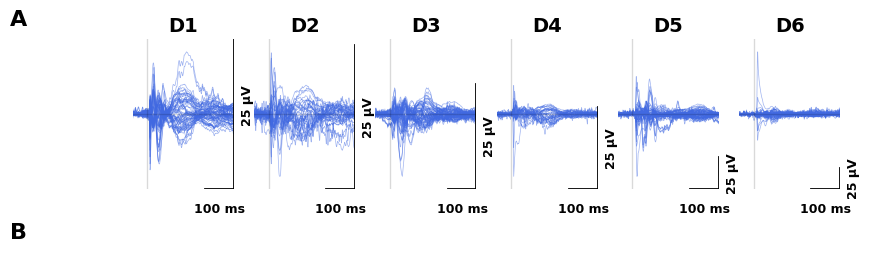

In [6]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

file_paths = [
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\1.Easycap+Brainamp+Nexstim\False_CX_nowind_alpha_nowind_alpha\6.pkls\prova_Betta_0001_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\4.Easycap+EBNeuro_amp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\TEPEMISFEROSXSTIMNETXTIMEASYCUP_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\2.Easycap+Brainamp+EBNeuro_stim\2025_02_26_103050_experiment-CX\6.pkls\prova_Betta_0002_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\3.Easycap+EBNeuro_amp+EBNeuro_stim\old\20250122183419-TEPEMISFEROSXEASYCUP-experiment\6.pkls\TEPEMISFEROSXEASYCUP_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\True_False_CX_nowind_biexpdouble_nowind_biexpdouble\6.pkls\CE20_07_08_2019_000004_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\False_Gaussian_CX_nowind_alpha_nowind_alpha\6.pkls\CE17_18_07_19_000003_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_powerlaw\6.pkls\prova_Mario_0003_epochs.pkl"
]

dataset_names = ["D1", "D2", "D3", "D4", "D5", "D6", "D7"]

fig = plt.figure(figsize=(11.69-1, 6.27-2))
gs = fig.add_gridspec(2, len(file_paths), height_ratios=[2, 2], hspace=0.2)

# Aggiunta delle lettere identificative
fig.text(0.01, 0.95, 'A', fontweight='bold', fontsize=16, va='top')
fig.text(0.01, 0.45, 'B', fontweight='bold', fontsize=16, va='top')

max_amplitudes = []
tep_axes = []
bar_heights = [25] * len(file_paths)

# === PANNELLI TEP ===
for idx, (path, name) in enumerate(zip(file_paths, dataset_names)):
    with open(path, 'rb') as f:
        data = pickle.load(f)

    data_array = data.get_data(copy=False)
    mean_data = np.mean(data_array, axis=0)
    times = data.times

    ax = fig.add_subplot(gs[0, idx])
    tep_axes.append(ax)

    # µV conversion
    scale = 1e6 if name != 'D2' else 1
    scaled_data = mean_data * scale

    # Plot
    for ch in scaled_data:
        ax.plot(times, ch, color='royalblue', alpha=0.5, linewidth=0.5)

    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.15)
    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.15)

    # Limiti
    peak = np.max(np.abs(scaled_data))
    ylim = (-1.2 * peak, 1.2 * peak)
    ax.set_ylim(ylim)
    ax.set_xlim(-0.05, 0.3)

    # === BARRETTE TEMPORALI ===
    amp_bar = bar_heights[idx]
    t_end = ax.get_xlim()[1]
    t_start = t_end - 0.1
    
    ylim = ax.get_ylim()
    neg_limit = ylim[0]  # è il valore negativo massimo (es. -40)
    y_bar = 1 * neg_limit  # posizionamento a 80% verso il basso
    ax.plot([t_start, t_end], [y_bar, y_bar], 'k', lw=2)
    #label_y_shift = 0.4 if idx >= 3 else 0.2
    #ax.text((t_start + t_end) / 2, y_bar - label_y_shift * amp_bar, '100 ms', ha='center', fontsize=9)
    ax.plot([t_end, t_end], [y_bar, y_bar + amp_bar], 'k', lw=2)
    #label_x_shift = 0.03 if idx >= 3 else 0.015
    #ax.text(t_end + label_x_shift, y_bar + amp_bar / 2, f'{amp_bar} µV',
    #        va='center', rotation='vertical', fontsize=9)
    from matplotlib.transforms import offset_copy
    
    # Etichetta "100 ms", con offset verticale costante
    ax.annotate('100 ms',
                xy=((t_start + t_end) / 2, y_bar), xycoords='data',
                textcoords='offset points', xytext=(0, -10),
                ha='center', va='top', fontsize=9)
    
    # Etichetta "25 µV", con offset orizzontale costante
    ax.annotate(f'{amp_bar} µV',
                xy=(t_end, y_bar + amp_bar / 2), xycoords='data',
                textcoords='offset points', xytext=(5, 0),
                ha='left', va='center', fontsize=9, rotation='vertical')


    
    # Axes cleanup
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(name)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for ch_idx in range(mean_data.shape[0]):
        signal = mean_data[ch_idx] * scale
        max_val = np.max(np.abs(signal))
        max_amplitudes.append({"Dataset": name, "Channel": ch_idx, "MaxAmplitude": max_val})

# === SWARM PLOT ===
df_max = pd.DataFrame(max_amplitudes)

# Calcolo Z-score intra-dataset per ciascun dato
df_max["ZscoreIntra"] = df_max.groupby("Dataset")["MaxAmplitude"].transform(zscore)

# === SWARM PLOT ===
df_max = pd.DataFrame(max_amplitudes)

# Calcolo Z-score intra-dataset per ciascun dato
df_max["ZscoreIntra"] = df_max.groupby("Dataset")["MaxAmplitude"].transform(zscore).abs()

# === SWARM PLOT AMPLITUDINI ===
ax_swarm = fig.add_subplot(gs[1, :])
sns.stripplot(data=df_max, x="Dataset", y="MaxAmplitude", ax=ax_swarm,
              size=3, color="black", alpha=0.8)
ax_swarm.set_ylabel("Amplitude (µV)")
ax_swarm.spines['top'].set_visible(False)
ax_swarm.spines['right'].set_visible(False)
ax_swarm.set_ylim(0, 100)

# === SWARM Z-SCORE SECONDARY AXIS ===
ax_z = ax_swarm.twinx()
sns.swarmplot(data=df_max, x="Dataset", y="ZscoreIntra", ax=ax_z,
              size=3, color="crimson", alpha=0)
ax_z.set_ylabel("Z-score", color="crimson")
ax_z.tick_params(axis='y', labelcolor='crimson')
ax_z.spines['top'].set_visible(False)
ax_z.spines['right'].set_color("crimson")
ax_z.set_ylabel("|Z-score| (σ)", color="crimson")
ax_z.set_yticks([0, 3, 6, 9])
for level in [0, 3, 6, 9]:
    ax_z.axhline(level, linestyle='--', color='crimson', alpha=0.4, linewidth=1)


# === SALVATAGGIO ===
save_dir = r"./paperFigures"
os.makedirs(save_dir, exist_ok=True)

fig.savefig(os.path.join(save_dir, "Figure_B.png"), bbox_inches="tight")
fig.savefig(os.path.join(save_dir, "Figure_B.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(save_dir, "Figure_B.svg"), bbox_inches="tight")
plt.show()


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

file_paths = [
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\1.Easycap+Brainamp+Nexstim\False_CX_nowind_alpha_nowind_alpha\6.pkls\prova_Betta_0001_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\4.Easycap+EBNeuro_amp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\TEPEMISFEROSXSTIMNETXTIMEASYCUP_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\2.Easycap+Brainamp+EBNeuro_stim\2025_02_26_103050_experiment-CX\6.pkls\prova_Betta_0002_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\3.Easycap+EBNeuro_amp+EBNeuro_stim\old\20250122183419-TEPEMISFEROSXEASYCUP-experiment\6.pkls\TEPEMISFEROSXEASYCUP_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\True_False_CX_nowind_biexpdouble_nowind_biexpdouble\6.pkls\CE20_07_08_2019_000004_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\False_Gaussian_CX_nowind_alpha_nowind_alpha\6.pkls\CE17_18_07_19_000003_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_powerlaw\6.pkls\prova_Mario_0003_epochs.pkl"
]

dataset_names = ["D1", "D2", "D3", "D4", "D5", "D6", "D7"]

# === Inizializzazione
max_amplitudes = []
bar_height = 25  # µV
fig = plt.figure(figsize=(10, len(file_paths) * 2))
gs = fig.add_gridspec(len(file_paths), 2, width_ratios=[2.5, 1.2], wspace=0.4)

# === Loop sui dataset ===
for idx, (path, name) in enumerate(zip(file_paths, dataset_names)):
    with open(path, 'rb') as f:
        data = pickle.load(f)

    data_array = data.get_data(copy=False)
    mean_data = np.mean(data_array, axis=0)
    times = data.times
    scale = 1e6 if name != 'D2' else 1
    scaled_data = mean_data * scale

    # === Subplot TEP ===
    ax_tep = fig.add_subplot(gs[idx, 0])
    for ch in scaled_data:
        ax_tep.plot(times, ch, color='royalblue', alpha=0.5, linewidth=0.5)

    ax_tep.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.15)
    ax_tep.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.15)
    ax_tep.set_xlim(-0.05, 0.3)

    # Limiti verticali
    peak = np.max(np.abs(scaled_data))
    ylim = (-1.2 * peak, 1.2 * peak)
    ax_tep.set_ylim(ylim)
    ax_tep.set_yticks([])
    ax_tep.set_xticks([])
    ax_tep.set_title(name, loc='left', fontsize=10)
    for spine in ax_tep.spines.values():
        spine.set_visible(False)

    # === Barre temporali e ampiezza ===
    t_end = ax_tep.get_xlim()[1]
    t_start = t_end - 0.1
    y_bar = ylim[0] * 0.9
    ax_tep.plot([t_start, t_end], [y_bar, y_bar], 'k', lw=2)
    ax_tep.plot([t_end, t_end], [y_bar, y_bar + bar_height], 'k', lw=2)
    ax_tep.annotate('100 ms', xy=((t_start + t_end) / 2, y_bar),
                    xytext=(0, -10), textcoords='offset points',
                    ha='center', va='top', fontsize=8)
    ax_tep.annotate(f'{bar_height} µV', xy=(t_end, y_bar + bar_height / 2),
                    xytext=(5, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=8, rotation='vertical')

    for ch_idx in range(mean_data.shape[0]):
        signal = mean_data[ch_idx] * scale
        max_val = np.max(np.abs(signal))
        max_amplitudes.append({"Dataset": name, "Channel": ch_idx, "MaxAmplitude": max_val})

# === SWARM PLOT ===
df_max = pd.DataFrame(max_amplitudes)
# Calcolo Z-score intra-dataset per ciascun dato
df_max["ZscoreIntra"] = df_max.groupby("Dataset")["MaxAmplitude"].transform(zscore).abs()


for idx, name in enumerate(dataset_names):
    ax_strip = fig.add_subplot(gs[idx, 1])
    sub_df = df_max[df_max["Dataset"] == name]
    sns.stripplot(data=sub_df, y="ZscoreIntra", ax=ax_strip, color='black', size=3, alpha=0.7, orient='h')
    #ax_strip.set_ylim(0, 6)
    ax_strip.set_ylabel("|Z-score| (σ)", fontsize=9)
    ax_strip.set_xticks([])
    ax_strip.set_title("", fontsize=9)
    ax_strip.spines['top'].set_visible(False)
    ax_strip.spines['right'].set_visible(False)

# === Salvataggio ===
save_dir = "./paperFigures_transposed"
os.makedirs(save_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Figure_B_verticale_ampZ.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "Figure_B_verticale_ampZ.svg"), bbox_inches="tight")
plt.show()


# fig XXX

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

def round_to_five_or_ten(x):
    """Arrotonda a multipli di 5 o 10 per miglior leggibilità."""
    abs_x = abs(x)
    if abs_x <= 10:
        return np.sign(x) * (5 * round(abs_x / 5))
    else:
        return np.sign(x) * (10 * round(abs_x / 10))

panel_configs = [
    {
        "subject": "Extreme Decay",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\prova_Mario_0003_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\prova_Mario_0003_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\prova_Mario_0003_detrendedEpochs.pkl"
            
        ]
    },
    {
        "subject": "CE20",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE20_07_08_2019_000004_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE20_07_08_2019_000004_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\CE20_07_08_2019_000004_detrendedEpochs.pkl"
        ]
    },
    {
        "subject": "CE17",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE17_18_07_19_000003_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE17_18_07_19_000003_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\CE17_18_07_19_000003_detrendedEpochs.pkl"
        ]
    }
]

col_titles = ["Artifacted TEP", "Not-Windowed Detrend", "Windowed Detrend"]
color_line = 'royalblue'

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10.7, 8.3), sharey=False, sharex=False)

for row_idx, subject_data in enumerate(panel_configs):
    subject = subject_data["subject"]
    file_paths = subject_data["file_paths"]

    for col_idx, file_path in enumerate(file_paths):
        with open(file_path, 'rb') as f:
            data = pickle.load(f)

        mean_data = np.mean(data_array, axis=0)
        times_ms = data.times * 1000

        ax = axes[row_idx, col_idx]
        row_letter = chr(ord('A') + row_idx)
        col_number = col_idx + 1
        label = f"{row_letter}-{col_number}"
        ax.text(0.01, 1.15, label, transform=ax.transAxes, fontweight='bold', va='top', ha='left')

        for ch in mean_data:
            ax.plot(times_ms, ch * 1e6, color=color_line, alpha=1, linewidth=0.25)

        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

        if row_idx == 0:
            ax.set_title(col_titles[col_idx], y=1.2)

        if col_idx == 0:
            ax.text(-0.2, 0.5, subject, transform=ax.transAxes,
                    fontsize=14, fontweight='bold', va='center', ha='right', rotation=90)

        # Arrotondamento tick Y
        y_vals = mean_data * 1e6
        y_min_raw = np.min(y_vals)
        y_max_raw = np.max(y_vals)
        if y_min_raw == y_max_raw:
            yticks = [0]
        else:
            y_min = round_to_five_or_ten(np.floor(y_min_raw))
            y_max = round_to_five_or_ten(np.ceil(y_max_raw))
            yticks = [y_min, y_max] if y_min < 0 and y_max > 0 else sorted(set([y_min, y_max]))
        ax.set_yticks(yticks)

        if row_idx != 2:
            ax.set_xticks([])
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Time (ms)", fontsize=10)

        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        if col_idx != 0:
            ax.yaxis.set_ticks_position('none')

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.text(0.0005, 0.5, "Amplitude (µV)", ha='center', va='center', rotation='vertical', fontweight='bold')

# Salvataggio
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/FigureC.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./paperFigures/FigureC.png", format="png", bbox_inches="tight")
fig.savefig("./paperFigures/FigureC.svg", format="svg", bbox_inches="tight")


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

def round_to_five_or_ten(x):
    """Arrotonda a multipli di 5 o 10 per miglior leggibilità."""
    abs_x = abs(x)
    if abs_x <= 10:
        return np.sign(x) * (5 * round(abs_x / 5))
    else:
        return np.sign(x) * (10 * round(abs_x / 10))

panel_configs = [
    {
        "subject": "Extreme Decay",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\prova_Mario_0003_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\prova_Mario_0003_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\False_Gaussian_CX_wind_singlerise_wind_singledecay\6.pkls\prova_Mario_0003_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\prova_Mario_0003_detrendedEpochs.pkl",
            #r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\prova_Mario_0003_postICA_final.pkl"

        ]
    },
    {
        "subject": "CE20",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE20_07_08_2019_000004_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE20_07_08_2019_000004_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\False_Gaussian_CX_wind_singlerise_wind_singledecay\6.pkls\CE20_07_08_2019_000004_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\CE20_07_08_2019_000004_detrendedEpochs.pkl",
            #r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\CE20_07_08_2019_000004_postICA_final.pkl",

        ]
    },
    {
        "subject": "CE17",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE17_18_07_19_000003_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\True_False_CX_nowind_biexp_nowind_biexp\6.pkls\CE17_18_07_19_000003_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\False_Gaussian_CX_wind_singlerise_wind_singledecay\6.pkls\CE17_18_07_19_000003_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\CE17_18_07_19_000003_detrendedEpochs.pkl",
            #r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\CE17_18_07_19_000003_postICA_final.pkl",

        ]
    }
]

col_titles = ["Artifacted Data", "Not-Windowed Detrend", "Windowed Detrend Exp", "Windowed Detrend Poly"]
color_line = 'royalblue'

def base_axis(ax):
    ax.spines[:].set_visible(False)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(t0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_xlabel('')

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 11), sharey=False, sharex=False)

for row_idx, subject_data in enumerate(panel_configs):
    subject = subject_data["subject"]
    file_paths = subject_data["file_paths"]

    for col_idx, file_path in enumerate(file_paths):
        with open(file_path, 'rb') as f:
            data = pickle.load(f)

        from scipy.signal import butter, filtfilt
        
        def bandpass_filter(data, srate, lowcut=1, highcut=30.0, order=4):
            nyq = 0.5 * srate
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return filtfilt(b, a, data, axis=-1)
        
        if col_titles[col_idx] != "Artifacted Data":
            data_array = data.get_data(copy=False)
            srate = data.info['sfreq']
            data_array = bandpass_filter(data_array, srate)
        else:
            data_array = data.get_data(copy=False)

        
        mean_data = np.mean(data_array, axis=0)
        times_ms = data.times * 1000
        mask = times_ms >= -50
        mean_data = mean_data[:, mask]
        times_ms = times_ms[mask]

        ax = axes[row_idx, col_idx]
        #row_letter = chr(ord('A') + row_idx)
        #col_number = col_idx + 1
        #label = f"{row_letter}-{col_number}"
        #ax.text(0.01, 1.15, label, transform=ax.transAxes, fontweight='bold', va='top', ha='left')

        for ch in mean_data:
            ax.plot(times_ms, ch * 1e6, color=color_line, alpha=1, linewidth=0.5)

        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

        if row_idx == 0:
            ax.set_title(col_titles[col_idx], y=1.2)

        if col_idx == 0:
            ax.text(-0.2, 0.5, subject, transform=ax.transAxes,
                    fontsize=14, fontweight='bold', va='center', ha='right', rotation=90)

        # Arrotondamento tick Y
        y_vals = mean_data * 1e6
        y_min_raw = np.min(y_vals)
        y_max_raw = np.max(y_vals)
        if y_min_raw == y_max_raw:
            yticks = [0]
        else:
            y_min = round_to_five_or_ten(np.floor(y_min_raw))
            y_max = round_to_five_or_ten(np.ceil(y_max_raw))
            yticks = [y_min, y_max] if y_min < 0 and y_max > 0 else sorted(set([y_min, y_max]))
        ax.set_yticks(yticks)

        if row_idx != 2:
            ax.set_xticks([])
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Time (ms)", fontsize=10)

        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        if col_idx != 0:
            ax.yaxis.set_ticks_position('none')
        
        # Vincolo asse Y per i pannelli 5, 6, 7 (seconda riga, colonne 1-3)
        if row_idx == 1 and col_idx in [1,2,3]:
            ax.set_ylim(-25, 30)
            ax.set_yticks([-25, 30])
            
        if row_idx == 2 and col_idx in [1, 2, 3]:
            ax.set_ylim(-15, 15)
            ax.set_yticks([-15, 15])

        #base_axis(ax)

plt.tight_layout(rect=[0, 0, 1, 0.97])
#fig.text(0.0005, 0.5, "Amplitude (µV)", ha='center', va='center', rotation='vertical', fontweight='bold')

# Salvataggio
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/FigureC.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./paperFigures/FigureC.png", format="png", bbox_inches="tight")
fig.savefig("./paperFigures/FigureC.svg", format="svg", bbox_inches="tight")


# supporting

In [32]:
# ─── Grid Search: MAE e MSE su tauRise e tauDecay ───────────────────────────────
tauRise_vals = np.linspace(1, 100, 25)
tauDecay_vals = np.linspace(25, 250, 25)
mae_grid = np.zeros((len(tauRise_vals), len(tauDecay_vals)))
mse_grid = np.zeros((len(tauRise_vals), len(tauDecay_vals)))

for i, tauR in enumerate(tauRise_vals):
    for j, tauD in enumerate(tauDecay_vals):
        # Genera nuovo artefatto
        charge_test = -carica_scarica(t, t0, t_peak, tauR, tauD) * k
        sum_signal_test = y + charge_test

        try:
            # Fit bi-esponenziale
            popt_test, _ = curve_fit(biexp, t_fit, sum_signal_test[mask_fit], p0=[1.0, 50, 100])
            fit_test = biexp(t_fit, *popt_test)
            
            # Errori
            mae_grid[i, j] = mean_absolute_error(sum_signal_test[mask_fit], fit_test)
            mse_grid[i, j] = mean_squared_error(sum_signal_test[mask_fit], fit_test)
        except RuntimeError:
            # In caso di non convergenza
            mae_grid[i, j] = np.nan
            mse_grid[i, j] = np.nan


C:\Users\verga\AppData\Local\Temp\ipykernel_25812\3882094039.py:48: RuntimeWarning: overflow encountered in exp
  return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)
C:\Users\verga\AppData\Local\Temp\ipykernel_25812\3882094039.py:48: RuntimeWarning: overflow encountered in multiply
  return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)
C:\Users\verga\AppData\Local\Temp\ipykernel_25812\3882094039.py:48: RuntimeWarning: overflow encountered in exp
  return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)
C:\Users\verga\AppData\Local\Temp\ipykernel_25812\3882094039.py:48: RuntimeWarning: overflow encountered in multiply
  return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)
C:\Users\verga\AppData\Local\Temp\ipykernel_25812\3882094039.py:48: RuntimeWarning: overflow encountered in exp
  return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)
C:\Users\verga\AppData\Local\Temp\ipykernel_25812\3882094039.py:48: RuntimeWarning: overflow encountered 